<a href="https://colab.research.google.com/github/pavnastia/airline-on-time-performance-analysis/blob/main/cz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## 1. Data overview

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Mate_homework

# Uploading dataset events.csv
events = pd.read_csv("events.csv")
events.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate_homework


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
# # Uploading dataset products.csv
products = pd.read_csv("products.csv")
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
# # Uploading dataset products.csv
countries = pd.read_csv("countries.csv")
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


# 1. Data Overview

Датасет складається з трьох таблиць: **events.csv**, **products.csv** та **countries.csv**.

## Таблиця `events.csv`

Містить інформацію про замовлення та продажі за декілька років.

| Колонка | Опис |
|---|---|
| **Order ID** | Унікальний ідентифікатор замовлення |
| **Order Date** | Дата оформлення замовлення |
| **Ship Date** | Дата відправлення замовлення |
| **Order Priority** | Пріоритет замовлення: `C` — Critical, `H` — High, `M` — Medium, `L` — Low |
| **Country Code** | Код країни, у якій було здійснено продаж |
| **Product ID** | Ідентифікатор товару |
| **Sales Channel** | Канал продажу: `Online` або `Offline` |
| **Units Sold** | Кількість проданих одиниць товару |
| **Unit Price** | Ціна продажу однієї одиниці товару |
| **Unit Cost** | Собівартість однієї одиниці товару |

---

## Таблиця `products.csv`

Містить довідкову інформацію про товари.

| Колонка | Опис |
|---|---|
| **id** | Унікальний ідентифікатор товару |
| **item_type** | Назва товару |

---

## Таблиця `countries.csv`

Містить довідкову інформацію про країни та їх географічну приналежність.

| Колонка | Опис |
|---|---|
| **name** | Назва країни |
| **alpha-2** | Дволітерний код країни за стандартом ISO, наприклад `AF` |
| **alpha-3** | Трилітерний код країни за стандартом ISO, наприклад `AFG` |
| **region** | Географічний регіон |
| **sub-region** | Географічний підрегіон |

---

## Ключові поля та зв'язки між таблицями

Таблиця **events.csv** є основною таблицею з даними про продажі, а **products.csv** та **countries.csv** містять додаткову довідкову інформацію.

Таблиці можна поєднати за такими ключами:

| Основна таблиця | Ключ | Довідкова таблиця | Ключ |
|---|---|---|---|
| `events.csv` | **Product ID** | `products.csv` | **id** |
| `events.csv` | **Country Code** | `countries.csv` | **alpha-3** |

Таким чином, після об'єднання трьох таблиць для кожного замовлення можна отримати не лише інформацію про продаж, але й **назву товару, країну, регіон та підрегіон**.

---
## 2. Data cleaning

In [ ]:
print(events.shape)
print(events.isna().sum())

(1330, 10)
Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64


In [ ]:
print(events.isna().sum() / events.shape[0] * 100)

Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [ ]:
events[events["Country Code"].isna()]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
13,104548490,1/1/2014,1/5/2014,M,NaN,7331,Online,7076.0,255.28,159.42
26,117929494,1/24/2015,3/2/2015,H,NaN,4594,Offline,6813.0,9.33,6.92
29,118859469,6/2/2011,7/1/2011,L,NaN,8969,Offline,2013.0,152.58,97.44
43,126948583,5/24/2017,7/9/2017,C,NaN,7331,Online,5762.0,255.28,159.42
...,...,...,...,...,...,...,...,...,...,...
1213,919922006,8/27/2011,9/18/2011,L,NaN,4594,Online,4219.0,9.33,6.92
1220,922564303,3/17/2017,4/2/2017,L,NaN,7940,Offline,6134.0,668.27,502.54
1250,941061675,3/8/2017,3/20/2017,M,NaN,5988,Offline,9917.0,154.06,90.93
1296,975080668,7/23/2017,8/20/2017,C,NaN,5988,Offline,6893.0,154.06,90.93


In [ ]:
events[events["Units Sold"].isna()]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
183,217165648,5/20/2014,6/8/2014,M,ESP,8875,Offline,NaN,421.89,364.69
319,309655511,5/5/2014,5/21/2014,C,HRV,3127,Offline,NaN,81.73,56.67


---

У таблиці `events.csv` виявлено пропущені значення у двох колонках:

- **Country Code** — **82 пропущені значення**, що становить приблизно **6.17%** від загальної кількості записів. Це досить вагома частка даних, тому видаляти відповідні рядки недоцільно, оскільки разом з ними буде втрачена інформація про продажі. Надалі пропущені значення в цій колонці будуть замінені на `Unknown`.

- **Units Sold** — **2 пропущені значення**, що становить приблизно **0.15%** від загальної кількості записів. Оскільки `Units Sold` показує кількість проданих одиниць товару та використовується для розрахунку виручки (`Revenue`), заміна пропусків середнім значенням може штучно змінити фінансові показники. Тому було прийнято рішення видалити ці 2 рядки. Через їх незначну частку така втрата даних не повинна суттєво вплинути на результати аналізу.

---

In [ ]:
events["Country Code"] = events["Country Code"].fillna("Unknown")

In [ ]:
events = events.dropna(subset=["Units Sold"])

In [ ]:
events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [ ]:
events.shape

(1328, 10)

---

In [ ]:
print(products.shape)
print(products.isna().sum())

(12, 2)
id           0
item_type    0
dtype: int64


---

У таблиці `products.csv` пропущених значень не виявлено, тому додаткової обробки пропусків ця таблиця не потребує.

---

In [ ]:
print(countries.shape)
print(countries.isna().sum())

(249, 5)
name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64


In [ ]:
print(countries.isna().sum() / countries.shape[0] * 100)

name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


In [ ]:
countries[countries["alpha-2"].isna()]

,name,alpha-2,alpha-3,region,sub-region
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


In [ ]:
countries[countries["region"].isna()]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN


---

У таблиці `countries.csv` виявлено **3 пропущені значення**:

- **alpha-2** — відсутній код для країни **Namibia**. Оскільки правильне значення відоме, пропуск можна відновити: дволітерний ISO-код Namibia — `NA`.
- **region** та **sub-region** — відсутні значення для **Antarctica**. Ці пропуски не є критичними, оскільки Antarctica не віднесена до окремого регіону та підрегіону в географічній класифікації, яка використовується в датасеті. Тому ці значення можна залишити пропущеними або позначити як `Not applicable`.

Таким чином, у `countries.csv` необхідно відновити лише відсутній код `alpha-2` для Namibia, а пропуски для Antarctica не свідчать про втрату важливої інформації.

---

In [ ]:
countries.loc[countries["name"] == "Namibia", "alpha-2"] = "NA"

In [ ]:
countries.loc[
    countries["name"] == "Antarctica",
    ["region", "sub-region"]
] = "Not applicable"

In [ ]:
countries[countries["name"].isin(["Namibia", "Antarctica"])]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,Not applicable,Not applicable
153,Namibia,NA,NAM,Africa,Sub-Saharan Africa


---


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1328 non-null   int64  
 1   Order Date      1328 non-null   object 
 2   Ship Date       1328 non-null   object 
 3   Order Priority  1328 non-null   object 
 4   Country Code    1328 non-null   object 
 5   Product ID      1328 non-null   int64  
 6   Sales Channel   1328 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1328 non-null   float64
 9   Unit Cost       1328 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 114.1+ KB


In [ ]:
events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 114.1+ KB


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     249 non-null    object
 2   alpha-3     249 non-null    object
 3   region      249 non-null    object
 4   sub-region  249 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


---

Після аналізу типів даних у трьох таблицях було виявлено, що в таблиці `events.csv` колонки **`Order Date`** та **`Ship Date`** мали тип `object` замість формату дати, тому їх було перетворено у тип **`datetime`**.

У таблицях `products.csv` та `countries.csv` типи даних у всіх колонках є коректними та не потребують додаткових змін.

---

In [ ]:
duplicate_rows = events.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0       False
1       False
2       False
3       False
4       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1328, dtype: bool
0


In [ ]:
duplicate_rows = products.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype: bool
0


In [ ]:
duplicate_rows = countries.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0      False
1      False
2      False
3      False
4      False
       ...  
244    False
245    False
246    False
247    False
248    False
Length: 249, dtype: bool
0


---

Після перевірки таблиць `events.csv`, `products.csv` та `countries.csv` дублікатів не виявлено. Дані не потребують додаткового очищення від повторюваних записів.

---

In [ ]:
# events.csv
print("Order Priority:", events["Order Priority"].unique())
print("Sales Channel:", events["Sales Channel"].unique())
print("Country Code:", events["Country Code"].unique())

# products.csv
print("Item Type:", products["item_type"].unique())

# countries.csv
print("Region:", countries["region"].unique())
print("Sub-region:", countries["sub-region"].unique())

Order Priority: ['M' 'C' 'L' 'H' ' C' 'M ']
Sales Channel: ['Online' 'Offline' 'online']
Country Code: ['NOR' 'SRB' 'Unknown' 'MNE' 'SVK' 'FRA' 'ESP' 'HRV' 'DEU' 'ARM' 'GEO'
 'GBR' 'SVN' 'ROU' 'POL' 'LUX' 'CYP' 'BEL' 'LTU' 'RUS' 'MLT' 'UKR' 'CZE'
 'PRT' 'BLR' 'EST' 'AUT' 'MKD' 'SMR' 'NLD' 'CHE' 'HUN' 'LVA' 'BGR' 'ITA'
 'IRL' 'AND' 'LIE' 'FIN' 'ALB' 'SWE' 'BIH' 'DNK' 'MCO' 'ISL' 'GRC']
Item Type: ['Cereal' 'Household' 'Clothes' 'Beverages' 'Office Supplies' 'Fruits'
 'Vegetables' 'Baby Food' 'Meat' 'Cosmetics' 'Snacks' 'Personal Care']
Region: ['Asia' 'Europe' 'Africa' 'Oceania' 'Americas' 'Not applicable']
Sub-region: ['Southern Asia' 'Northern Europe' 'Southern Europe' 'Northern Africa'
 'Polynesia' 'Sub-Saharan Africa' 'Latin America and the Caribbean'
 'Not applicable' 'Western Asia' 'Australia and New Zealand'
 'Western Europe' 'Eastern Europe' 'Northern America' 'South-eastern Asia'
 'Eastern Asia' 'Melanesia' 'Micronesia' 'Central Asia']


In [ ]:
events["Order Priority"].value_counts()

,count
Order Priority,
M,352
H,335
L,334
C,304
C,2
M,1


In [ ]:
events["Order Priority"] = events["Order Priority"].str.strip().str.upper()

In [ ]:
events["Order Priority"].value_counts()

,count
Order Priority,
M,353
H,335
L,334
C,306


In [ ]:
events["Sales Channel"].value_counts()

,count
Sales Channel,
Offline,665
Online,660
online,3


In [ ]:
events["Sales Channel"] = events["Sales Channel"].str.strip().str.capitalize()

In [ ]:
events["Sales Channel"].value_counts()

,count
Sales Channel,
Offline,665
Online,663


---

Після додаткової перевірки категоріальних значень у таблицях `events.csv`, `products.csv` та `countries.csv` було виявлено неточності лише в окремих значеннях колонок **`Order Priority`** та **`Sales Channel`** у таблиці `events.csv`. Вони були пов'язані із зайвими пробілами та різним регістром літер і були виправлені.

В інших категоріальних колонках таблиць `products.csv` та `countries.csv` додаткових неточностей або неузгоджених значень не виявлено.

---

In [ ]:
events.describe()

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


In [ ]:
# Чи є доставка раніше дати замовлення
events[events["Ship Date"] < events["Order Date"]]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


In [ ]:
# Чи є собівартість вищою за ціну продажу
events[events["Unit Cost"] > events["Unit Price"]]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


---

За результатами описової статистики `.describe()` явних аномальних значень у числових показниках не виявлено. Значення `Units Sold`, `Unit Price` та `Unit Cost` знаходяться в логічних межах і не містять нульових або від'ємних значень.

Для додаткової перевірки даних також було перевірено логічну узгодженість дат та фінансових показників.

---

# 2. Data Cleaning

На цьому етапі було проведено перевірку таблиць `events.csv`, `products.csv` та `countries.csv` на пропущені значення, некоректні типи даних, дублікати, неузгоджені категоріальні значення та можливі аномалії.

## Пропущені значення

### Таблиця `events.csv`

У таблиці було виявлено пропущені значення у двох колонках:

- **Country Code** — **82 пропущені значення**, що становить приблизно **6.17%** від загальної кількості записів. Це досить вагома частка даних, тому видаляти відповідні рядки недоцільно, оскільки разом із ними буде втрачена інформація про продажі. Пропущені значення було замінено на `Unknown`.

- **Units Sold** — **2 пропущені значення**, що становить приблизно **0.15%** від загальної кількості записів. Оскільки `Units Sold` показує кількість проданих одиниць товару та надалі може використовуватися для розрахунку виручки (`Revenue`) та інших фінансових показників, заміна пропусків середнім значенням могла б штучно змінити результати. Тому було прийнято рішення видалити ці 2 рядки. Через їх незначну частку така втрата даних не повинна суттєво вплинути на результати аналізу.

Точну причину виникнення пропусків визначити неможливо. Ймовірно, вони могли виникнути через неповне заповнення початкових даних або помилки під час їх збору чи експорту.

### Таблиця `products.csv`

У таблиці `products.csv` пропущених значень не виявлено, тому додаткової обробки пропусків не проводилось.

### Таблиця `countries.csv`

У таблиці було виявлено **3 пропущені значення**:

- у колонці **alpha-2** був відсутній код для країни **Namibia**. Правильне значення було відновлено — `NA`;
- у колонках **region** та **sub-region** були відсутні значення для **Antarctica**. Оскільки ці значення не визначені в структурі даних як звичайний регіон та підрегіон, вони були позначені як `Not applicable`.

---

## Перевірка типів даних

Після аналізу типів даних було виявлено, що в таблиці `events.csv` колонки **Order Date** та **Ship Date** мали тип `object` замість формату дати. Для коректної подальшої роботи з датами їх було перетворено у тип `datetime`.

У таблицях `products.csv` та `countries.csv` типи даних у всіх колонках є коректними та не потребували додаткових змін.

---

## Перевірка дублікатів та категоріальних значень

Таблиці `events.csv`, `products.csv` та `countries.csv` було перевірено на наявність повністю дубльованих рядків. Повних дублікатів не виявлено.

Додатково було перевірено категоріальні значення на можливі неточності, пов'язані із зайвими пробілами та різним регістром літер.

У таблиці `events.csv` були виявлені неузгоджені значення:

- у колонці **Order Priority** деякі однакові категорії відображались окремо через зайві пробіли. Значення були очищені та приведені до єдиного формату;
- у колонці **Sales Channel** були значення `Online` та `online`. Значення були приведені до єдиного формату: `Online` та `Offline`.

Після додаткової перевірки категоріальних колонок у таблицях `products.csv` та `countries.csv` інших неточностей або неузгоджених значень не виявлено.

---

## Перевірка на аномалії

Для числових даних у таблиці `events.csv` було проведено аналіз описової статистики за допомогою `describe()`.

Явних аномальних значень не виявлено:

- **Units Sold** містить додатні значення в межах від 1 до 9999;
- **Unit Price** містить додатні значення в межах від 9.33 до 668.27;
- **Unit Cost** містить додатні значення в межах від 6.92 до 524.96;
- дати замовлень охоплюють період з 2010 по 2017 рік, що відповідає структурі датасету.

На основі описової статистики значення знаходяться в логічних межах, тому явних аномалій, які потребували б видалення або коригування, не виявлено.

---

### Висновок

У процесі очищення даних було опрацьовано пропущені значення, виправлено некоректні типи дат та приведено категоріальні значення до єдиного формату. Повних дублікатів та явних аномальних значень не виявлено.

Після проведеного очищення дані є більш узгодженими та готовими до подальшого об'єднання таблиць, розрахунку додаткових показників і проведення аналізу.

---
## 3. Data analysis and visualization

In [ ]:
# Об'єднуємо дані про продажі з інформацією про товари
sales_data = events.merge(
    products,
    how="left",
    left_on="Product ID",
    right_on="id",
    validate="many_to_one"
)

# Додаємо інформацію про країни та регіони
sales_data = sales_data.merge(
    countries,
    how="left",
    left_on="Country Code",
    right_on="alpha-3",
    validate="many_to_one"
)

# Видаляємо зайві колонки-ключі після об'єднання
sales_data = sales_data.drop(columns=["id", "alpha-3", "alpha-2"])

# Перейменовуємо колонки для зручнішого аналізу
sales_data = sales_data.rename(columns={
    "Order ID": "order_id",
    "Order Date": "order_date",
    "Ship Date": "ship_date",
    "Order Priority": "order_priority",
    "Country Code": "country_code",
    "Product ID": "product_id",
    "Sales Channel": "sales_channel",
    "Units Sold": "units_sold",
    "Unit Price": "unit_price",
    "Unit Cost": "unit_cost",
    "name": "country_name",
    "sub-region": "sub_region"
})

# Заповнюємо відсутню географічну інформацію значенням "Unknown"
sales_data[["country_name", "region", "sub_region"]] = (
    sales_data[["country_name", "region", "sub_region"]]
    .fillna("Unknown")
)

sales_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,Household,Unknown,Unknown,Unknown
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


In [ ]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1328 non-null   int64  
 1   order_date      1328 non-null   object 
 2   ship_date       1328 non-null   object 
 3   order_priority  1328 non-null   object 
 4   country_code    1328 non-null   object 
 5   product_id      1328 non-null   int64  
 6   sales_channel   1328 non-null   object 
 7   units_sold      1328 non-null   float64
 8   unit_price      1328 non-null   float64
 9   unit_cost       1328 non-null   float64
 10  item_type       1328 non-null   object 
 11  country_name    1328 non-null   object 
 12  region          1328 non-null   object 
 13  sub_region      1328 non-null   object 
dtypes: float64(3), int64(2), object(9)
memory usage: 145.4+ KB


In [ ]:
# Розрахунок фінансових метрик
sales_data["revenue"] = sales_data["units_sold"] * sales_data["unit_price"]  # Загальна виручка
sales_data["total_cost"] = sales_data["units_sold"] * sales_data["unit_cost"]  # Загальні витрати
sales_data["profit"] = sales_data["revenue"] - sales_data["total_cost"]  # Загальний прибуток


sales_data["order_date"] = pd.to_datetime(sales_data["order_date"], format="%m/%d/%Y")
sales_data["ship_date"] = pd.to_datetime(sales_data["ship_date"], format="%m/%d/%Y")

sales_data["delivery_days"] = (sales_data["ship_date"] - sales_data["order_date"]).dt.days  # Тривалість доставки

In [ ]:
sales_data[["order_date", "ship_date", "delivery_days"]].head()

,order_date,ship_date,delivery_days
0,2014-10-08,2014-10-18,10
1,2016-08-11,2016-08-11,0
2,2014-07-18,2014-08-11,24
3,2017-05-13,2017-06-13,31
4,2012-08-11,2012-09-18,38


In [ ]:
sales_data[["order_date", "ship_date", "delivery_days"]].dtypes

,0
order_date,datetime64[ns]
ship_date,datetime64[ns]
delivery_days,int64


In [ ]:
# Основні KPI компанії

total_orders = sales_data["order_id"].nunique()
total_revenue = sales_data["revenue"].sum()
total_cost = sales_data["total_cost"].sum()
total_profit = sales_data["profit"].sum()
total_units = sales_data["units_sold"].sum()
total_countries = sales_data.loc[sales_data["country_name"] != "Unknown", "country_name"].nunique()
avg_delivery = sales_data["delivery_days"].mean()

print(f"Загальна кількість замовлень: {total_orders:,}")
print(f"Загальна виручка: ${total_revenue:,.2f}")
print(f"Загальні витрати: ${total_cost:,.2f}")
print(f"Загальний прибуток: ${total_profit:,.2f}")
print(f"Кількість охоплених країн: {total_countries}")
print(f"Загальна кількість проданих одиниць: {total_units:,.0f}")
print(f"Середня тривалість доставки: {avg_delivery:.1f} днів")

Загальна кількість замовлень: 1,328
Загальна виручка: $1,702,129,408.21
Загальні витрати: $1,200,694,949.21
Загальний прибуток: $501,434,459.00
Кількість охоплених країн: 45
Загальна кількість проданих одиниць: 6,576,524
Середня тривалість доставки: 24.8 днів


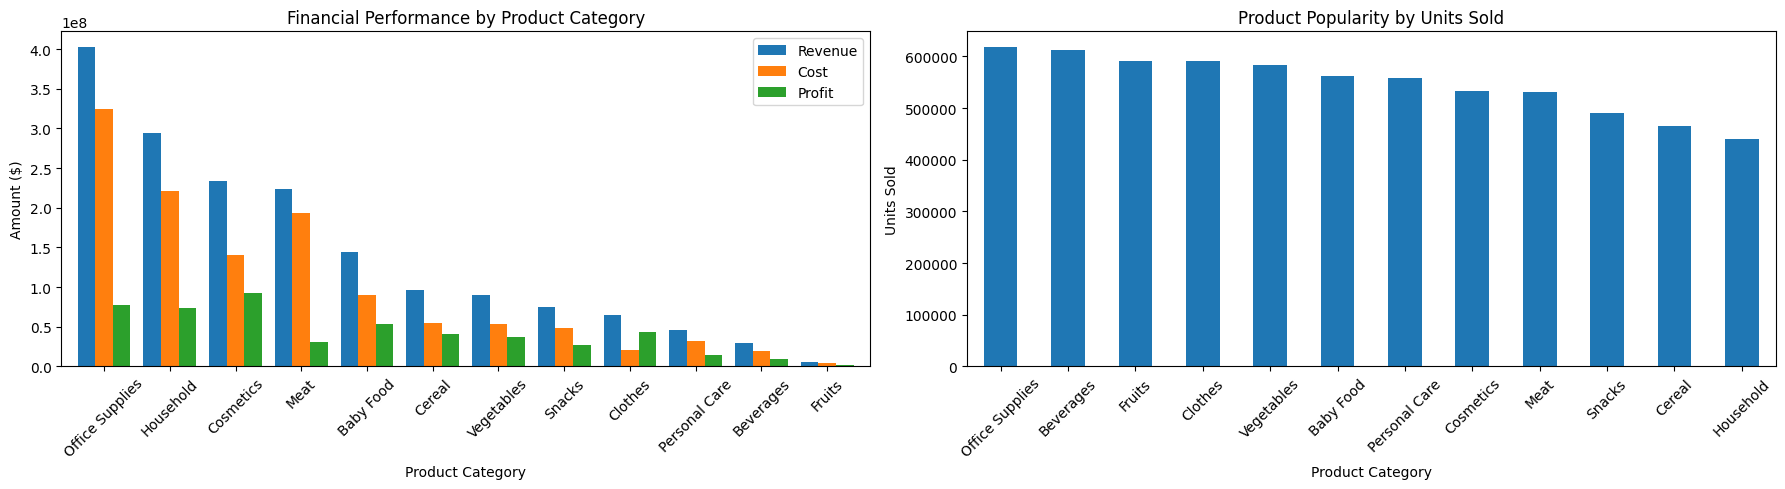

In [ ]:
# Аналіз категорій товарів: фінансові показники + популярність
fig, axes = plt.subplots(1, 2, figsize=(18, 5))


# Популярність товарів за кількістю проданих одиниць
category_financials = (
    sales_data
    .groupby("item_type")[["revenue", "total_cost", "profit"]]
    .sum()
    .sort_values(by="revenue", ascending=False)
)

category_financials.columns = ["Revenue", "Cost", "Profit"]

category_financials.plot(
    kind="bar",
    ax=axes[0],
    width=0.8
)

axes[0].set_title("Financial Performance by Product Category")
axes[0].set_ylabel("Amount ($)")
axes[0].set_xlabel("Product Category")
axes[0].tick_params(axis="x", rotation=45)


# Популярність товарів за кількістю проданих одиниць
product_popularity = (
    sales_data
    .groupby("item_type")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)

product_popularity.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Product Popularity by Units Sold")
axes[1].set_ylabel("Units Sold")
axes[1].set_xlabel("Product Category")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

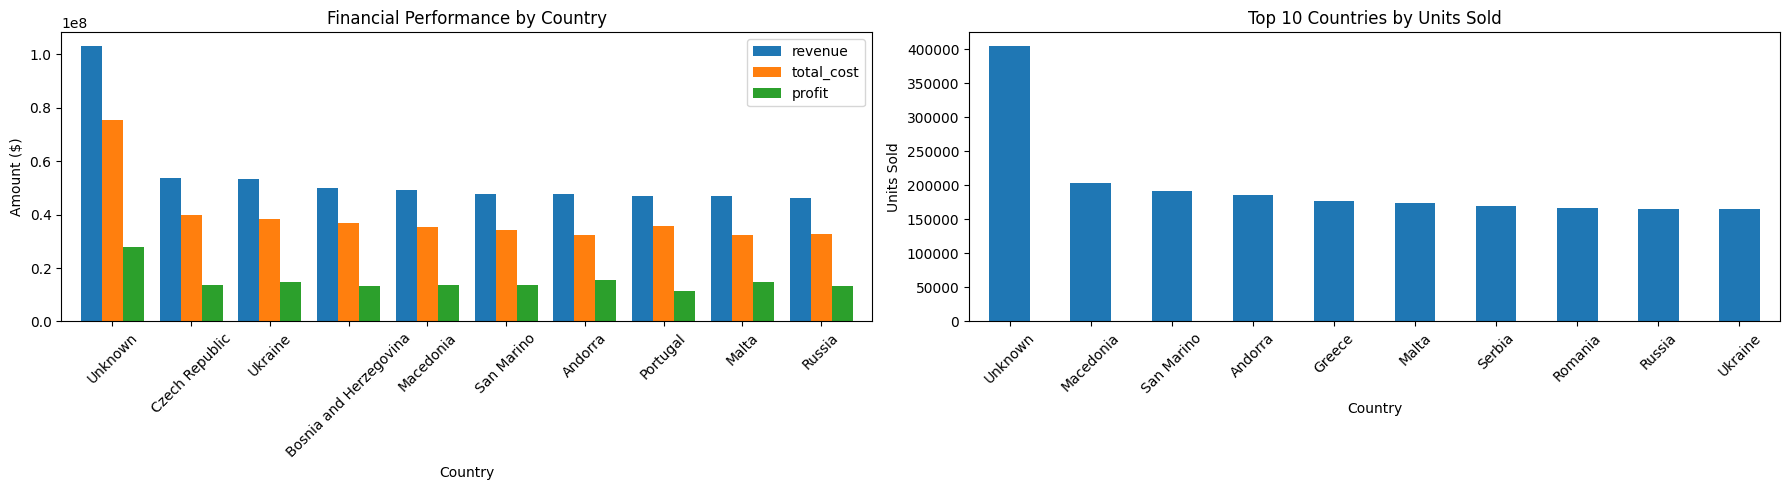

In [ ]:
# Аналіз за країнами: фінансові показники + кількість проданих одиниць
fig, axes = plt.subplots(1, 2, figsize=(18, 5))


# Фінансові показники за країнами
country_financials = (
    sales_data
    .groupby("country_name")[["revenue", "total_cost", "profit"]]
    .sum()
    .sort_values(by="revenue", ascending=False)
    .head(10)
)

country_financials.plot(
    kind="bar",
    ax=axes[0],
    width=0.8
)

axes[0].set_title("Financial Performance by Country")
axes[0].set_ylabel("Amount ($)")
axes[0].set_xlabel("Country")
axes[0].tick_params(axis="x", rotation=45)


# Кількість проданих одиниць за країнами
country_units = (
    sales_data
    .groupby("country_name")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_units.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Top 10 Countries by Units Sold")
axes[1].set_ylabel("Units Sold")
axes[1].set_xlabel("Country")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

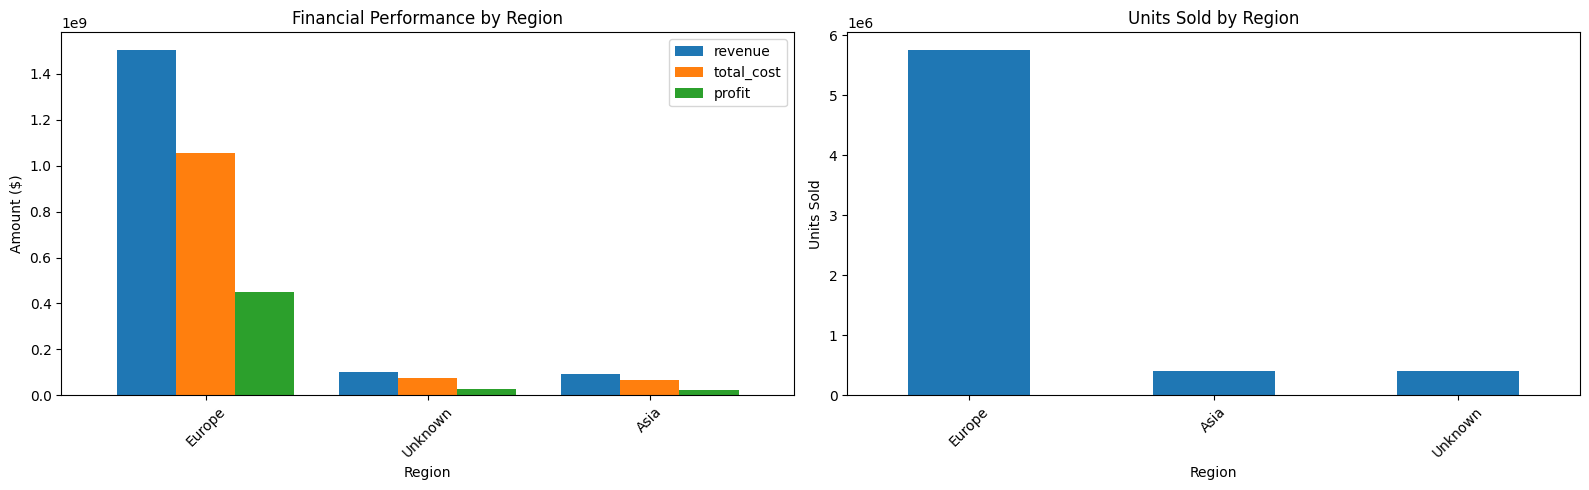

In [ ]:
# Аналіз за регіонами: фінансові показники + кількість проданих одиниць
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Фінансові показники за регіонами
region_financials = (
    sales_data
    .groupby("region")[["revenue", "total_cost", "profit"]]
    .sum()
    .sort_values(by="revenue", ascending=False)
)

region_financials.plot(
    kind="bar",
    ax=axes[0],
    width=0.8
)

axes[0].set_title("Financial Performance by Region")
axes[0].set_ylabel("Amount ($)")
axes[0].set_xlabel("Region")
axes[0].tick_params(axis="x", rotation=45)


# Кількість проданих одиниць за регіонами
region_units = (
    sales_data
    .groupby("region")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)

region_units.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Units Sold by Region")
axes[1].set_ylabel("Units Sold")
axes[1].set_xlabel("Region")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

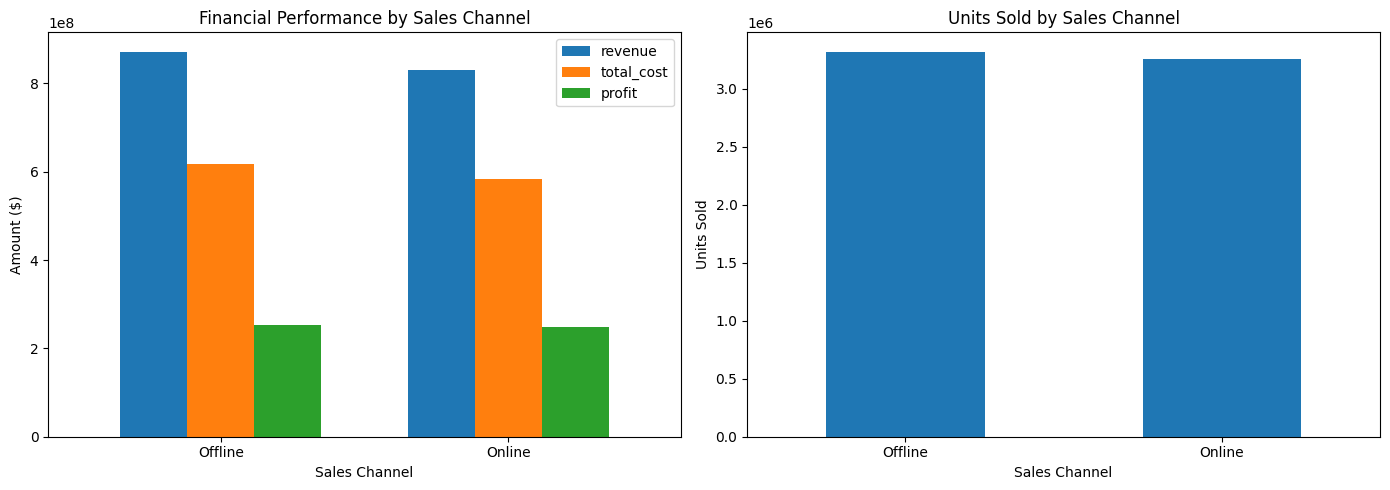

In [ ]:
# Аналіз за каналами продажу: фінансові показники + кількість проданих одиниць
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Фінансові показники за каналами продажу
channel_financials = (
    sales_data
    .groupby("sales_channel")[["revenue", "total_cost", "profit"]]
    .sum()
)

channel_financials.plot(
    kind="bar",
    ax=axes[0],
    width=0.7
)

axes[0].set_title("Financial Performance by Sales Channel")
axes[0].set_ylabel("Amount ($)")
axes[0].set_xlabel("Sales Channel")
axes[0].tick_params(axis="x", rotation=0)


# Кількість проданих одиниць за каналами продажу
channel_units = (
    sales_data
    .groupby("sales_channel")["units_sold"]
    .sum()
)

channel_units.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Units Sold by Sales Channel")
axes[1].set_ylabel("Units Sold")
axes[1].set_xlabel("Sales Channel")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

---

# Аналіз продажів

## Категорії товарів

За фінансовими показниками лідером є категорія **Office Supplies**: її виручка становить **400 млн дол.**, а кількість проданих одиниць — **620 тис.** Це **24%** загальної виручки компанії, тому категорія має суттєвий вплив на загальний результат.

Високу виручку також мають **Household** — 294 млн дол., **Cosmetics** — 234 млн дол. та **Meat** — 224 млн дол.

Найбільший прибуток серед категорій демонструє **Cosmetics** — 93 млн дол., хоча кількість проданих одиниць цієї категорії становить 535 тис. і вона не є лідером за популярністю. Для порівняння, **Office Supplies** має більший обсяг продажів — 620 тис. одиниць, але прибуток становить 77 млн дол. Це показує, що найбільший обсяг продажів у штуках не обов'язково означає найбільший прибуток.

Особливо це помітно для **Beverages** та **Fruits**. Вони входять до найпопулярніших категорій за кількістю проданих одиниць — 610 тис. та 590 тис. відповідно, але мають одні з найнижчих показників виручки та прибутку.

Отже, для оцінки ефективності асортименту необхідно враховувати не лише кількість проданих одиниць, а й фінансовий результат кожної категорії.

---

## Географія продажів

У розрізі країн найбільші показники має категорія **Unknown**: виручка становить **103 млн дол.**, прибуток — **28 млн дол.**, а кількість проданих одиниць перевищує **400 тис.**

Це реальні продажі, для яких країну не вдалося визначити через відсутній **Country Code**. Таких записів у початкових даних було **82**, або **6.17%**, тому їх збереження є важливим для фінансового аналізу. Водночас така частка невідомої географії знижує точність порівняння окремих країн.

Серед відомих країн найвищі показники виручки мають **Czech Republic** — 54 млн дол., **Ukraine** — 53 млн дол. та **Bosnia and Herzegovina** — 50 млн дол.

За кількістю проданих одиниць серед відомих країн виділяються **Macedonia** — 202 тис. одиниць, **San Marino** — 192 тис. та **Andorra** — 186 тис.

У розрізі регіонів абсолютним лідером є **Europe**. Він формує 1.5 млрд дол. виручки, 450 млн дол. прибутку та 5.8 млн проданих одиниць. Це 89% загальної виручки та 88% усіх проданих одиниць.

Для порівняння, виручка **Asia** становить 90 млн дол., а кількість проданих одиниць — 0.4 млн. Отже, бізнес компанії значною мірою сконцентрований на європейському ринку.

---

## Канали продажу

Продажі через **Online** та **Offline** канали розподілені майже порівну.

Через **Offline** канал отримано **870 млн дол.** виручки, тоді як через **Online — 830 млн дол.** Таким чином, на **Offline** припадає **51% виручки**, а на **Online — 49%**.

Прибуток також відрізняється незначно: 255 млн дол. для **Offline** та 245 млн дол. для **Online**.

За кількістю проданих одиниць через **Offline** реалізовано 3.3 млн одиниць, а через **Online** — 3.25 млн.

Отже, обидва канали мають важливе значення для компанії, а перевага **Offline** є незначною.

---

### Висновок

Продажі компанії сильно сконцентровані в **Europe**, який формує **89%** загальної виручки та **88%** обсягу продажів у штуках.

Серед товарів найбільший внесок у виручку робить **Office Supplies — 400 млн дол.**, тоді як найбільший прибуток демонструє **Cosmetics — 93 млн дол.**

Аналіз також показує, що популярність товару не завжди відповідає його прибутковості: **Beverages** і **Fruits** входять до лідерів за кількістю проданих одиниць, але мають значно нижчі фінансові результати.

**Online** та **Offline** канали фактично поділяють виручку у співвідношенні **49%** та **51%**, тому обидва канали мають важливе значення для бізнесу.

---

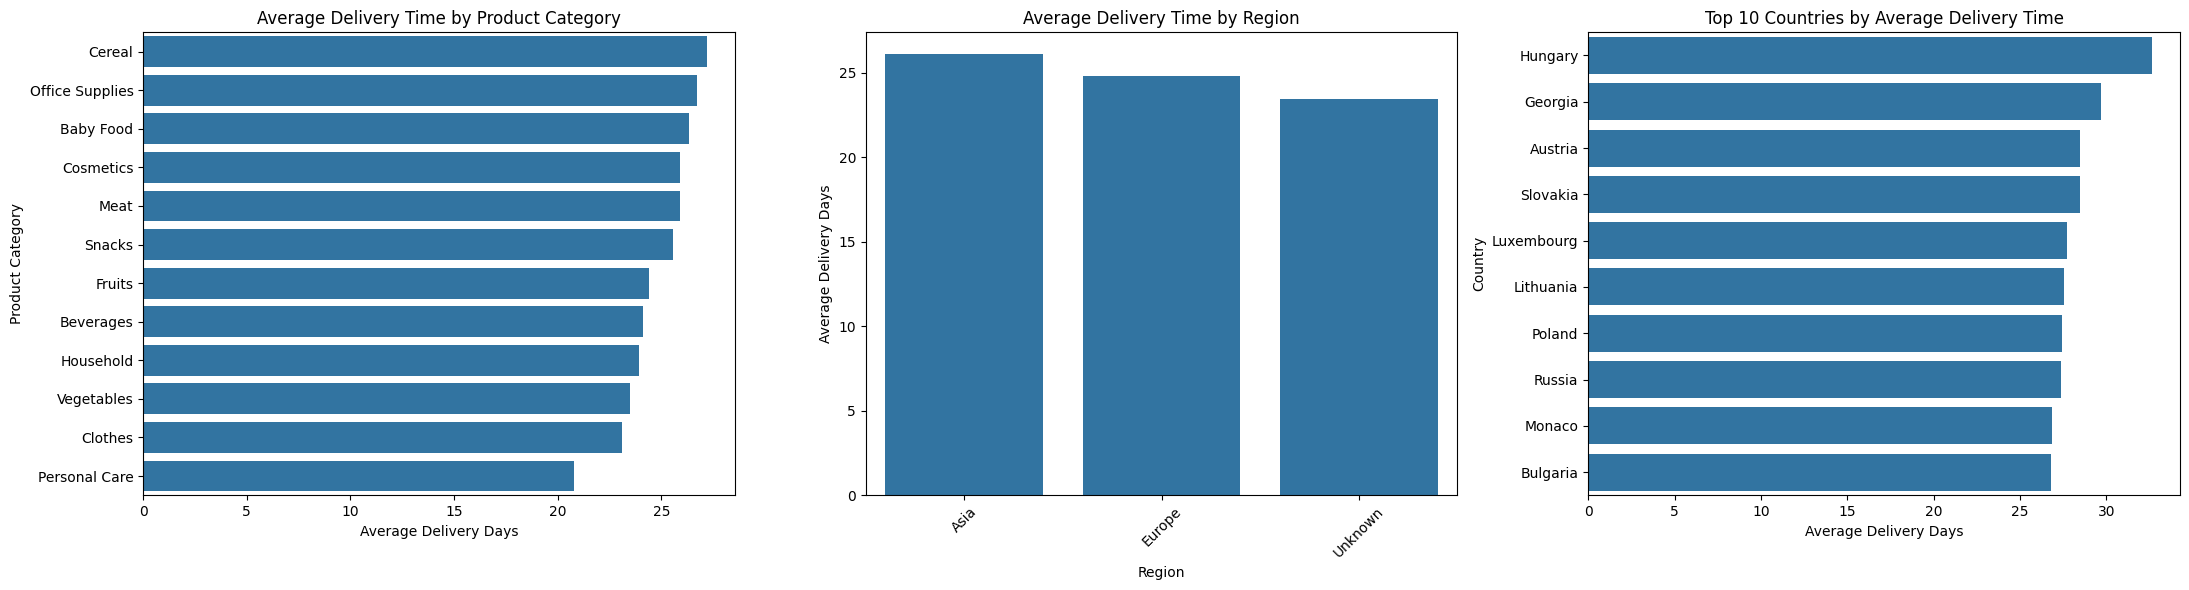

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Середній час доставки за категоріями товарів
category_delivery = (
    sales_data
    .groupby("item_type")["delivery_days"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=category_delivery.values,
    y=category_delivery.index,
    ax=axes[0]
)

axes[0].set_title("Average Delivery Time by Product Category")
axes[0].set_xlabel("Average Delivery Days")
axes[0].set_ylabel("Product Category")


# Середній час доставки за регіонами
region_delivery = (
    sales_data
    .groupby("region")["delivery_days"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=region_delivery.index,
    y=region_delivery.values,
    ax=axes[1]
)

axes[1].set_title("Average Delivery Time by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Average Delivery Days")
axes[1].tick_params(axis="x", rotation=45)


# Топ-10 країн за найдовшим середнім часом доставки
country_delivery = (
    sales_data
    .groupby("country_name")["delivery_days"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=country_delivery.values,
    y=country_delivery.index,
    ax=axes[2]
)

axes[2].set_title("Top 10 Countries by Average Delivery Time")
axes[2].set_xlabel("Average Delivery Days")
axes[2].set_ylabel("Country")

plt.tight_layout()
plt.show()

# Аналіз часу між замовленням та відвантаженням

## Категорії товарів

Середня тривалість доставки для більшості категорій товарів знаходиться приблизно в межах **23–27 днів**.

Найдовший середній час доставки має категорія **Cereal** — близько **27 днів**. Також відносно довгий термін доставки спостерігається для **Office Supplies** та **Baby Food**.

Найменший середній час доставки має категорія **Personal Care** — близько **21 дня**. Також швидше за інші доставляються товари категорії **Clothes**.

Загалом різниця між більшістю категорій є невеликою, тому категорія товару не має дуже сильного впливу на тривалість доставки.

---

## Країни

Серед країн найдовший середній час доставки спостерігається в **Hungary** — понад **32 дні**.

Також відносно довгий термін доставки мають **Georgia**, **Austria** та **Slovakia** — приблизно **29–30 днів**.

До Top 10 країн із найдовшим середнім часом доставки також входять **Luxembourg, Lithuania, Poland, Russia, Monaco** та **Bulgaria**.

Отже, саме на рівні окремих країн різниця в термінах доставки є більш помітною, ніж між категоріями товарів.

---

## Регіони

Серед регіонів найбільший середній час доставки має **Asia** — приблизно **26 днів**.

Для **Europe** середній термін доставки становить близько **25 днів**, а для категорії **Unknown** — приблизно **23–24 дні**.

Різниця між регіонами є відносно невеликою, однак у **Asia** доставка в середньому займає трохи більше часу.

---

## Висновок

У більшості випадків середній час між замовленням та відвантаженням становить **21–27 днів**.

Найменші відмінності спостерігаються між категоріями товарів і регіонами, тоді як на рівні країн розрив є більш помітним. Найбільше виділяється **Hungary** із середнім часом доставки **32 дні**.

З бізнес-точки зору це означає, що основну увагу доцільно приділяти не стільки окремим товарним категоріям, скільки конкретним країнам і регіонам, де доставка займає більше часу. Особливо це стосується **Asia**, де поєднуються довший час відвантаження та нижчі обсяги продажів.

---

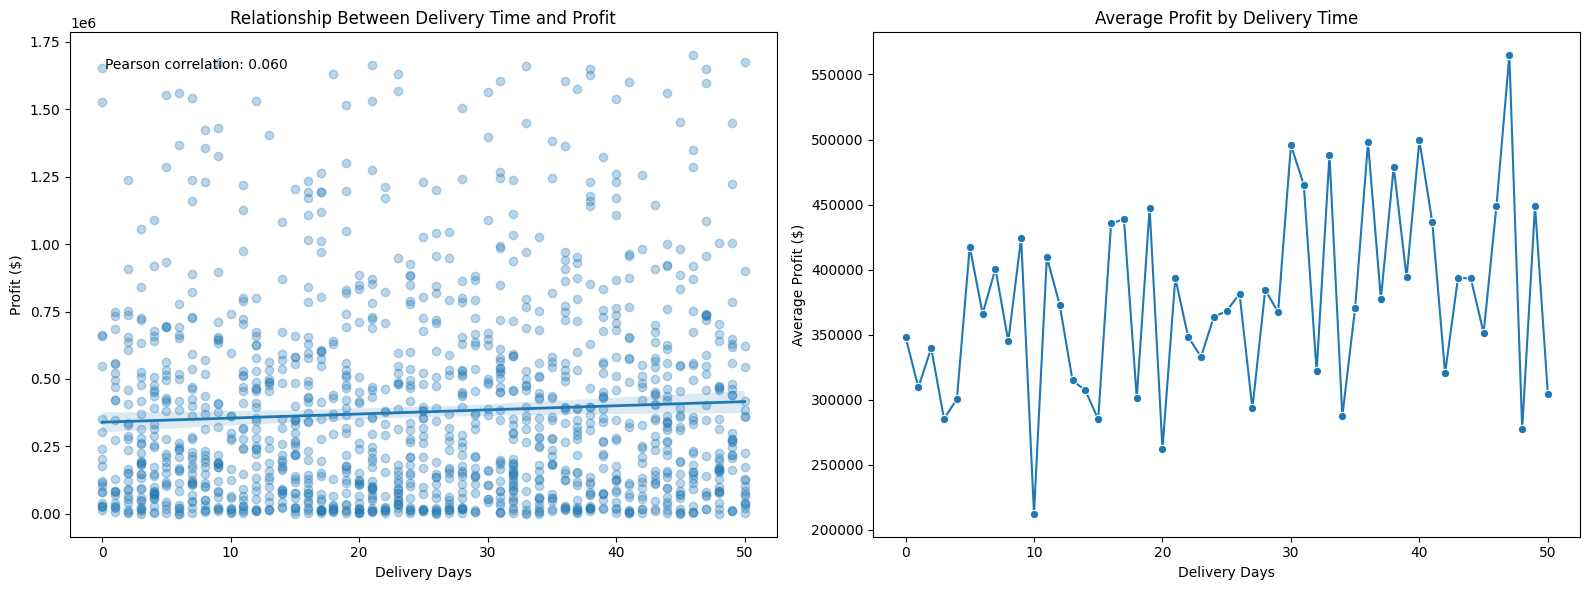

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Залежність між часом доставки та прибутком
sns.regplot(
    data=sales_data,
    x="delivery_days",
    y="profit",
    ax=axes[0],
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2}
)

# Розрахунок кореляції між часом доставки та прибутком
correlation = sales_data["delivery_days"].corr(sales_data["profit"])

axes[0].set_title("Relationship Between Delivery Time and Profit")
axes[0].set_xlabel("Delivery Days")
axes[0].set_ylabel("Profit ($)")
axes[0].text(
    0.05, 0.95,
    f"Pearson correlation: {correlation:.3f}",
    transform=axes[0].transAxes,
    verticalalignment="top"
)

profit_by_delivery = (
    sales_data
    .groupby("delivery_days")
    .agg(
        avg_profit=("profit", "mean"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

profit_by_delivery.head()

# Середній прибуток залежно від часу доставки
sns.lineplot(
    data=profit_by_delivery,
    x="delivery_days",
    y="avg_profit",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Average Profit by Delivery Time")
axes[1].set_xlabel("Delivery Days")
axes[1].set_ylabel("Average Profit ($)")

plt.tight_layout()
plt.show()

---
### Зв'язок між швидкістю доставки та прибутком

Для перевірки залежності прибутку від часу, необхідного на відвантаження товару, було проаналізовано зв'язок між `delivery_days` та `profit`.

Коефіцієнт кореляції Пірсона становить **0.060**, що свідчить про дуже слабкий лінійний зв'язок між тривалістю відвантаження та прибутком.

На графіку розсіювання точки мають значний розкид при всіх значеннях delivery_days, а лінія тренду майже горизонтальна. На агрегованому графіку середній прибуток залежно від часу відвантаження коливається від **&#36;0.21 млн** до **&#36;0.57 млн**, але послідовного зростання або зниження зі збільшенням кількості днів не спостерігається.

Отже, збільшення або скорочення часу відвантаження в межах **0–50 днів** не демонструє помітного зв'язку з прибутком. На основі наявних даних можна зробити висновок, що **прибуток практично не залежить від часу, необхідного на відвантаження товару**.

---

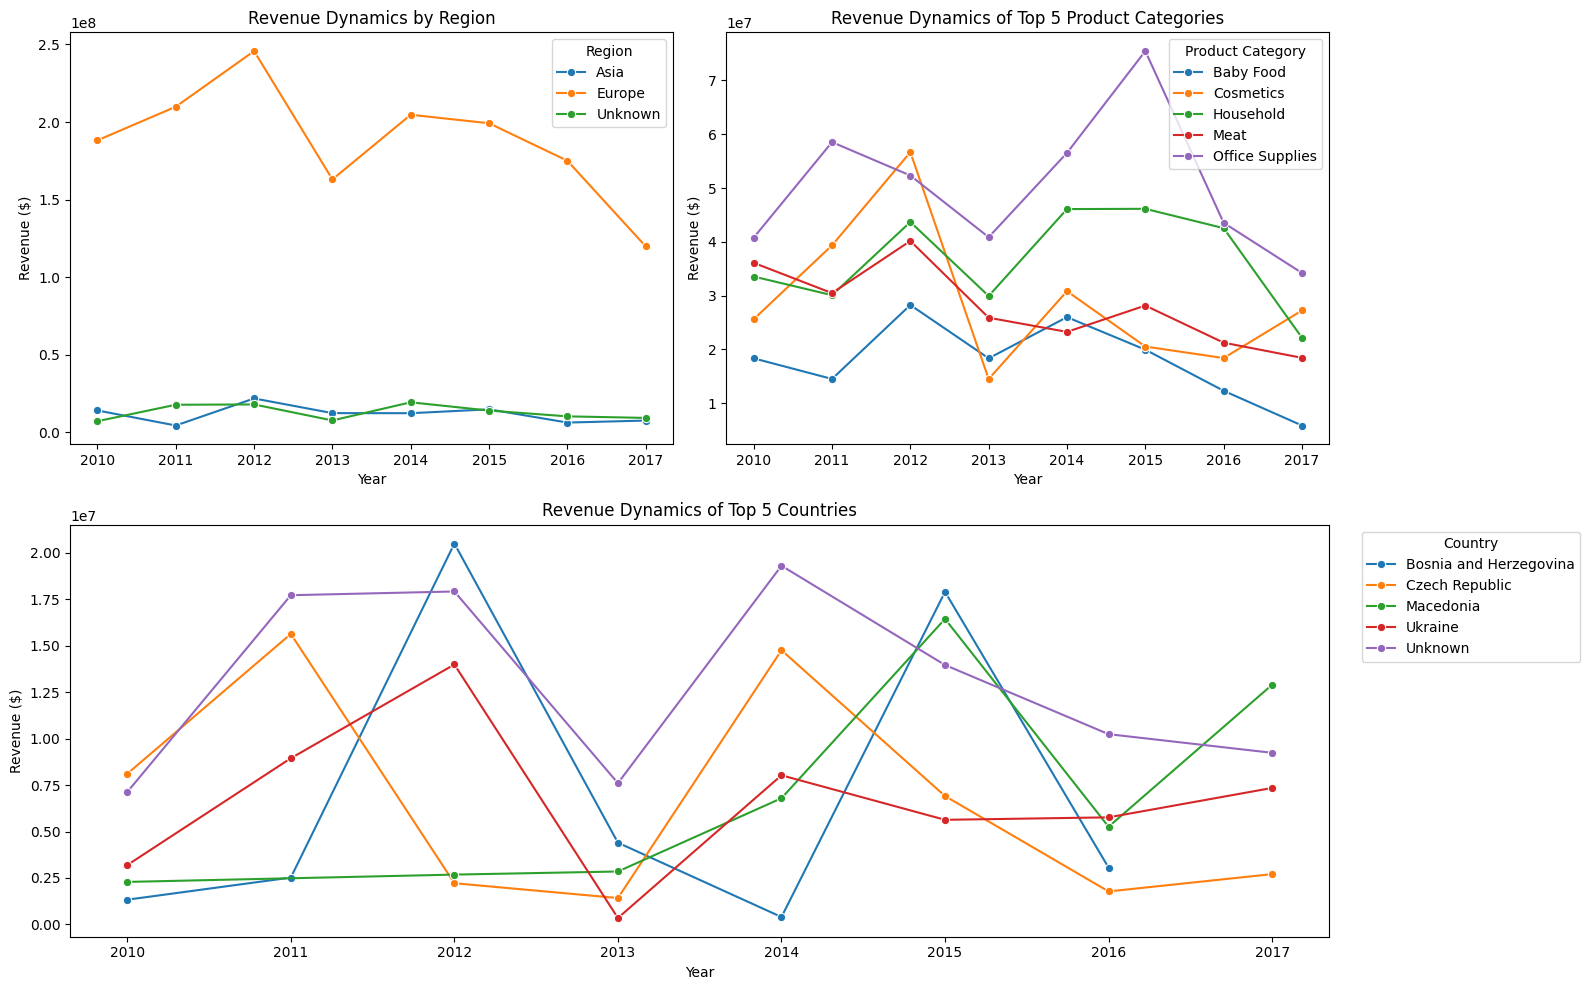

In [ ]:
sales_data["year"] = sales_data["order_date"].dt.year

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])   # зверху ліворуч
ax2 = fig.add_subplot(gs[0, 1])   # зверху праворуч
ax3 = fig.add_subplot(gs[1, :])   # внизу на всю ширину


# Динаміка виручки за регіонами
region_year = (
    sales_data
    .groupby(["year", "region"])["revenue"]
    .sum()
    .reset_index()
)

sns.lineplot(
    data=region_year,
    x="year",
    y="revenue",
    hue="region",
    marker="o",
    ax=ax1
)

ax1.set_title("Revenue Dynamics by Region")
ax1.set_xlabel("Year")
ax1.set_ylabel("Revenue ($)")
ax1.legend(title="Region")


# Динаміка виручки топ-5 категорій товарів
top5_categories = (
    sales_data
    .groupby("item_type")["revenue"]
    .sum()
    .nlargest(5)
    .index
)

category_year = (
    sales_data[sales_data["item_type"].isin(top5_categories)]
    .groupby(["year", "item_type"])["revenue"]
    .sum()
    .reset_index()
)

sns.lineplot(
    data=category_year,
    x="year",
    y="revenue",
    hue="item_type",
    marker="o",
    ax=ax2
)

ax2.set_title("Revenue Dynamics of Top 5 Product Categories")
ax2.set_xlabel("Year")
ax2.set_ylabel("Revenue ($)")
ax2.legend(title="Product Category")


# Динаміка виручки топ-5 країн
top5_countries = (
    sales_data
    .groupby("country_name")["revenue"]
    .sum()
    .nlargest(5)
    .index
)

country_year = (
    sales_data[sales_data["country_name"].isin(top5_countries)]
    .groupby(["year", "country_name"])["revenue"]
    .sum()
    .reset_index()
)

sns.lineplot(
    data=country_year,
    x="year",
    y="revenue",
    hue="country_name",
    marker="o",
    ax=ax3
)

ax3.set_title("Revenue Dynamics of Top 5 Countries")
ax3.set_xlabel("Year")
ax3.set_ylabel("Revenue ($)")
ax3.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

---

# Аналіз динаміки продажів у часі

Для аналізу динаміки продажів у часі використано показник **Revenue**, оскільки він відображає загальний обсяг продажів у грошовому вираженні за кожен рік.

---

## Динаміка за регіонами

Основна частина виручки протягом усього досліджуваного періоду припадає на **Europe**.  
У 2010 році виручка регіону становила **188 млн дол.**, у 2011 році — **210 млн дол.**, а пікового значення досягла у **2012 році — 245 млн дол.**

Після цього у 2013 році виручка Europe знизилася до **163 млн дол.**, у 2014 році знову зросла до **204 млн дол.**, у 2015 році залишалася на високому рівні — **199 млн дол.**, а далі зменшилася до **175 млн дол.** у 2016 році та **120 млн дол.** у 2017 році.

Продажі в **Asia** протягом усього періоду були значно нижчими: у різні роки виручка коливалася в межах приблизно **4–22 млн дол.**  
Для категорії **Unknown** показники також залишалися набагато нижчими за Europe і змінювалися приблизно в межах **7–20 млн дол.**

Отже, саме **Europe** стабільно формує основну частину продажів компанії.

---

## Динаміка за категоріями товарів

Серед п’яти провідних категорій найбільшу виручку в більшості років демонструє **Office Supplies**.  
У 2010 році вона становила близько **41 млн дол.**, у 2011 — **59 млн дол.**, у 2014 — **57 млн дол.**, а максимуму досягла у **2015 році — 76 млн дол.** Після цього виручка знизилася до **44 млн дол.** у 2016 році та **35 млн дол.** у 2017 році.

Категорія **Household** також має високі показники: **34 млн дол.** у 2010 році, **44 млн дол.** у 2012 році та **46 млн дол.** у 2014–2015 роках. У 2017 році її виручка знизилася до **22 млн дол.**

Для **Cosmetics** характерні помітні коливання. Виручка зросла з **26 млн дол.** у 2010 році до **57 млн дол.** у 2012 році, після чого різко впала до **15 млн дол.** у 2013 році. У наступні роки вона коливалася в межах **18–31 млн дол.**

Категорія **Meat** демонструє відносно високі, але нестабільні значення: від **18 млн дол.** до **40 млн дол.** залежно від року.

Для **Baby Food** виручка змінювалася від **6 млн дол.** у 2017 році до **28 млн дол.** у 2012 році.

Таким чином, у розрізі товарних категорій спостерігаються **річні коливання**, а не стабільне довгострокове зростання.

---

## Динаміка за країнами

У розрізі країн також помітні значні коливання між роками.

Категорія **Unknown** формує суттєву частину виручки: **7 млн дол.** у 2010 році, **18 млн дол.** у 2011–2012 роках, **19 млн дол.** у 2014 році та **9 млн дол.** у 2017 році. Це означає, що помітна частина продажів не може бути точно віднесена до конкретної країни.

**Bosnia and Herzegovina** демонструє дуже нестабільну динаміку: у 2012 році виручка перевищила **20 млн дол.**, у 2015 році становила близько **18 млн дол.**, тоді як в окремі інші роки була в кілька разів нижчою.

**Czech Republic** мала високі показники у **2011 році — близько 16 млн дол.** та у **2014 році — близько 15 млн дол.**, після чого виручка зменшилася.

**Macedonia** до 2014 року мала відносно помірні значення в межах **2–7 млн дол.**, зате у **2015 році** виручка зросла до **16.5 млн дол.**, а у **2017 році** — до **12.9 млн дол.**

Для **Ukraine** пік виручки спостерігався у **2012 році — близько 14 млн дол.**, після чого показники знизилися та надалі коливалися в межах приблизно **5–8 млн дол.**

Отже, на рівні окремих країн динаміка продажів є **нерівномірною**, з вираженими піками та спадами.

---

## Висновок

Динаміка продажів у 2010–2017 роках не демонструє стабільного довгострокового зростання.  
Основним регіоном продажів залишається **Europe**, який у всі роки суттєво випереджає **Asia** та **Unknown** за обсягом виручки.

Серед товарних категорій найбільший внесок у виручку найчастіше робить **Office Supplies**, а також вагомими залишаються **Household**, **Cosmetics** та **Meat**. У розрізі країн спостерігаються суттєві річні коливання, тому продажі компанії залежать від окремих сильних періодів у конкретних країнах і категоріях.

Важливо враховувати, що **2017 рік може бути неповним**, тому нижчі значення за цей рік не варто одразу трактувати як підтверджений спад.

---

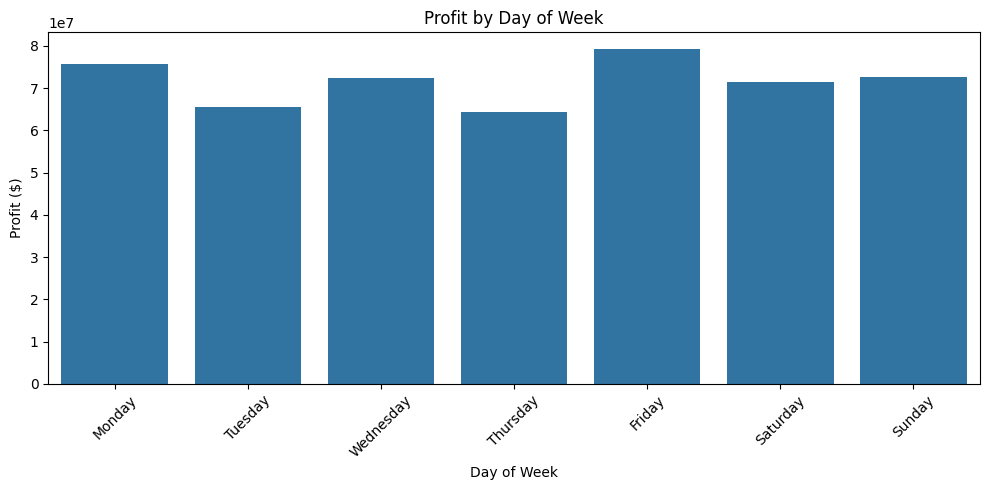

In [ ]:
sales_data["day_of_week"] = sales_data["order_date"].dt.day_name()

days_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_profit = (
    sales_data
    .groupby("day_of_week")["profit"]
    .sum()
    .reindex(days_order)
    .reset_index()
)

# Аналіз прибутку за днями тижня
plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday_profit,
    x="day_of_week",
    y="profit",
    errorbar=None
)

plt.title("Profit by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Profit ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


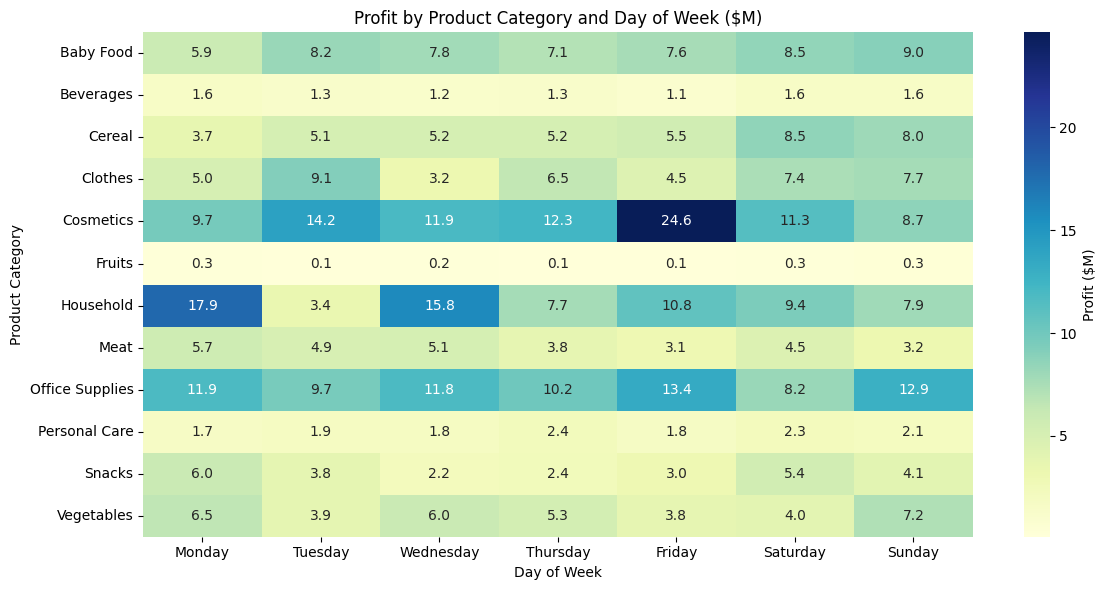

In [ ]:
# Прибуток категорій товарів за днями тижня
plt.figure(figsize=(12, 6))

pivot_profit = sales_data.pivot_table(
    index="item_type",
    columns="day_of_week",
    values="profit",
    aggfunc="sum"
)[days_order]

pivot_profit_millions = pivot_profit / 1_000_000

sns.heatmap(
    pivot_profit_millions,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f",
    cbar_kws={"label": "Profit ($M)"}
)

plt.title("Profit by Product Category and Day of Week ($M)")
plt.xlabel("Day of Week")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

---
## Аналіз продажів за днями тижня та тижневої сезонності

Загальний прибуток компанії змінюється залежно від дня тижня. Найвищий результат спостерігається у **Friday** — **79.3 млн дол**., а найнижчий у **Thursday** — **64.3 млн дол**. Різниця становить **15 млн дол.**, або **23.3%**. У **Tuesday** прибуток також є відносно низьким — **65.6 млн дол**.

У розрізі товарних категорій спостерігаються більш виражені тижневі патерни.

**Cosmetics** має найбільший пік у **Friday — 24.6 млн дол.** Для порівняння, у **Sunday** прибуток цієї категорії становить 8.7 млн дол., тобто у **Friday** він майже у 3 рази вищий.

**Household** демонструє найвищий прибуток у **Monday — 17.9 млн дол.** та **Wednesday** — 15.8 млн дол., тоді як у **Tuesday** показник знижується до 3.4 млн дол.

Для **Cereal** помітно вищі результати у вихідні: **8.5 млн дол.** у **Saturday** та 8.0 млн дол. у **Sunday**, тоді як у **Monday** прибуток становить 3.7 млн дол.

**Clothes** має найвищий результат у **Tuesday — 9.1 млн дол.**, а також високі показники у **Saturday** — 7.4 млн дол. та **Sunday** — 7.7 млн дол.

**Baby Food** також демонструє зростання ближче до вихідних: прибуток збільшується з *5.9 млн дол. у Monday до 9.0 млн дол. у Sunday.

Водночас у **Beverages**, **Fruits** та **Personal Care** значення між днями тижня змінюються значно менше. Наприклад, прибуток **Beverages** знаходиться в межах 1.1–1.6 млн дол., а **Personal Care** — 1.7–2.4 млн дол.

Отже, за агрегованими даними найбільш виражені тижневі патерни мають **Cosmetics, Household, Cereal та Clothes**. Їх можна розглядати як категорії з тижневою сезонністю, тоді як для **Beverages, Fruits та Personal Care** залежність від дня тижня є слабшою.

---
---

# Фінальний аналітичний звіт: ключові показники та тенденції продажів компанії (2010–2017 рр.)

## Основні результати

### 1. Категорії товарів

Найбільшу виручку формує категорія **Office Supplies — 400 млн дол., або 24% загальної виручки компанії**. За кількістю проданих одиниць ця категорія також є лідером — **620 тис. одиниць**.

Високу виручку мають Household — 294 млн дол., Cosmetics — 234 млн дол. та Meat — 224 млн дол.

Найбільший прибуток серед категорій демонструє **Cosmetics — 93 млн дол.** При цьому кількість проданих одиниць Cosmetics становить 535 тис., тобто категорія не є лідером за популярністю. Для порівняння, Office Supplies продається в кількості 620 тис. одиниць, але приносить 77 млн дол. прибутку.

Це показує, що **популярність товару не завжди прямо відповідає його прибутковості**.

Особливо це видно на прикладі Beverages та Fruits: обсяг їх продажів становить 610 тис. та 590 тис. одиниць відповідно, однак фінансові результати цих категорій є одними з найнижчих.

---

### 2. Географія продажів

Основна частина бізнесу компанії припадає на **Europe**. Регіон формує **1.5 млрд дол. виручки, 450 млн дол. прибутку та 5.8 млн проданих одиниць**.

На Europe припадає **89% загальної виручки та 88% усіх проданих одиниць**, тому компанія має високу концентрацію продажів на європейському ринку.

Для порівняння, виручка Asia становить 90 млн дол., а кількість проданих одиниць — 0.4 млн.

У розрізі країн найбільші показники має категорія **Unknown: 103 млн дол. виручки, 28 млн дол. прибутку та понад 400 тис. проданих одиниць**.

Причиною появи Unknown є відсутність Country Code у **82 записах, або 6.17% початкових даних**. Ці записи були збережені, щоб не втрачати реальну інформацію про продажі, однак така частка невизначеної географії знижує точність аналізу окремих країн.

Серед відомих країн найбільшу виручку мають Czech Republic — 54 млн дол., Ukraine — 53 млн дол. та Bosnia and Herzegovina — 50 млн дол.

---

### 3. Канали продажу

Online та Offline канали мають майже рівний внесок у результат компанії.

Offline формує **870 млн дол. виручки, або 51%**, а Online — **830 млн дол., або 49%**.

Прибуток становить 255 млн дол. для Offline та 245 млн дол. для Online.

За кількістю проданих одиниць також немає суттєвої різниці: 3.3 млн одиниць продано через Offline та 3.25 млн через Online.

Отже, **обидва канали є однаково важливими для бізнесу**.

---

### 4. Час між замовленням та відвантаженням

Середній час між замовленням та відвантаженням залежно від товарної категорії знаходиться в межах **21–27 днів**.

Найдовший середній час має Cereal — 27 днів, а найкоротший Personal Care — 21 день.

На рівні регіонів **Asia має середній час відвантаження 26 днів**, Europe — 25 днів, а Unknown — 23–24 дні.

Найбільші відмінності спостерігаються між окремими країнами. **Hungary має найдовший середній час — 32 дні**, Georgia — 30 днів, Austria та Slovakia — по 29 днів.

Таким чином, **логістичні відмінності сильніше проявляються на рівні конкретних країн**, ніж на рівні категорій товарів або регіонів.

---

### 5. Залежність прибутку від часу відвантаження

Коефіцієнт кореляції Пірсона між кількістю днів до відвантаження та прибутком становить **0.060**.

Значення дуже близьке до нуля, тому **вираженого лінійного зв'язку між часом відвантаження та прибутком немає**.

Середній прибуток для різної тривалості відвантаження коливається в межах 0.21–0.57 млн дол., але зі збільшенням часу доставки від 0 до 50 днів не спостерігається стабільного зростання або зменшення прибутку.

Отже, **час відвантаження не можна вважати фактором, який суттєво визначає прибутковість замовлення**.

---

### 6. Динаміка продажів у часі

**Europe залишається основним джерелом виручки протягом усього досліджуваного періоду.**

Виручка Europe зросла з 188 млн дол. у 2010 році до **максимального значення 245 млн дол. у 2012 році**. У 2013 році вона знизилася до 163 млн дол., після чого відновилася до 204 млн дол. у 2014 році та 199 млн дол. у 2015 році.

Серед товарних категорій особливо виділяється Office Supplies. Її виручка становила 41 млн дол. у 2010 році та досягла **76 млн дол. у 2015 році**.

Cosmetics досягла піку **57 млн дол. у 2012 році**, після чого у 2013 році виручка знизилася до 15 млн дол.

У розрізі країн продажі характеризуються значними річними коливаннями.

Загалом дані **не демонструють стабільного довгострокового зростання**: для регіонів, категорій та країн характерні окремі періоди зростання і спаду.

**Важливо:** дані за 2017 рік охоплюють лише частину року, тому нижчі значення за цей період не можна трактувати як підтверджене падіння продажів.

---

### 7. Прибуток за днями тижня та тижневі патерни

Найвищий загальний прибуток компанія отримує у **Friday — 79.3 млн дол.**

Найнижчий результат спостерігається у **Thursday — 64.3 млн дол.** Різниця між Friday та Thursday становить **15 млн дол., або 23.3%**.

У розрізі категорій найбільш виражені тижневі патерни мають **Cosmetics, Household, Cereal та Clothes**.

Cosmetics приносить **24.6 млн дол. прибутку у Friday**, тоді як у Sunday — 8.7 млн дол. Тобто результат Friday **майже у 3 рази вищий**.

Household має 17.9 млн дол. прибутку у Monday та 15.8 млн дол. у Wednesday, тоді як у Tuesday — лише 3.4 млн дол.

Для Cereal найкращими є вихідні: 8.5 млн дол. у Saturday та 8.0 млн дол. у Sunday.

Clothes має максимальний результат у Tuesday — 9.1 млн дол., а також високі показники у Saturday — 7.4 млн дол. та Sunday — 7.7 млн дол.

Отже, **окремі категорії мають виражені тижневі патерни прибутковості**, які можна враховувати під час планування продажів і маркетингової активності.

---

## Загальний бізнес-висновок

Основним ринком компанії є **Europe, який формує 89% загальної виручки та 88% проданих одиниць**. Це одночасно є сильною стороною бізнесу та ризиком високої залежності від одного регіону.

Ключовою категорією за виручкою є **Office Supplies — 400 млн дол., або 24% загального показника**, тоді як найбільший прибуток приносить **Cosmetics — 93 млн дол.**

Online та Offline канали практично однаково важливі для компанії: вони формують **49% та 51% виручки відповідно**.

Asia суттєво поступається Europe за обсягом продажів: **90 млн дол. проти 1.5 млрд дол. виручки**. Водночас середній час відвантаження в Asia становить 26 днів проти 25 днів у Europe.

Прямого зв'язку між часом відвантаження та прибутком не виявлено: **коефіцієнт кореляції становить 0.060**.

Також виявлено виражені тижневі патерни окремих категорій. Найбільш показовим є **Cosmetics: 24.6 млн дол. прибутку у Friday**, що майже у 3 рази перевищує результат Sunday.

---

## Рекомендації

- **Підтримувати достатні запаси Office Supplies**, оскільки категорія формує 400 млн дол. виручки та 24% загального показника компанії.

- **Приділити окрему увагу Cosmetics** як найбільш прибутковій категорії з результатом 93 млн дол. та враховувати її сильний пік у Friday — 24.6 млн дол.

- **Покращити заповнення Country Code**. Частка записів без визначеної країни становить 6.17%, а група Unknown формує 103 млн дол. виручки.

- **Зберігати та розвивати обидва канали продажу**, оскільки Offline формує 51% виручки, а Online — 49%.

- **Окремо проаналізувати Asia**: виручка регіону становить лише 90 млн дол. порівняно з 1.5 млрд дол. у Europe, а середній час відвантаження є довшим — 26 проти 25 днів.